In [1]:
import geopandas as gpd

In [2]:
gdf = gpd.read_file(
    "../data/raw/Local_Authority_Districts_DEC_2025_Boundaries_UK_BGC_-4525566687348132669.geojson"
)

In [3]:
gdf.head()

,FID,LAD25CD,LAD25NM,LAD25NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,1,E06000001,Hartlepool,,447161,531473,-1.270174,54.67613,1fdf4842-ef98-44b3-b42a-2d6f63ef8715,"MULTIPOLYGON (((449812.86630 525823.71910, 449..."
1,2,E06000002,Middlesbrough,,451141,516887,-1.210998,54.54468,d437678a-50a7-4643-a5a2-62a4e1114a6e,"MULTIPOLYGON (((446860.00000 517200.30000, 446..."
2,3,E06000003,Redcar and Cleveland,,464330,519596,-1.006565,54.56752,1f21ae23-7451-40a0-a38a-43e296357326,"MULTIPOLYGON (((451747.39690 520561.10040, 451..."
3,4,E06000004,Stockton-on-Tees,,444940,518179,-1.306646,54.55688,6354091f-fe54-4ad6-8803-88f4147c7687,"MULTIPOLYGON (((446997.14600 517642.74400, 446..."
4,5,E06000005,Darlington,,428029,515648,-1.568356,54.53534,3b22b28b-a859-4138-9b8b-bb0b049fd63e,"POLYGON ((423475.70080 524731.59660, 423497.20..."


In [4]:
gdf.shape

(361, 10)

In [5]:
gdf.columns.tolist()

['FID',
 'LAD25CD',
 'LAD25NM',
 'LAD25NMW',
 'BNG_E',
 'BNG_N',
 'LONG',
 'LAT',
 'GlobalID',
 'geometry']

In [6]:
kent_names = [
    "Ashford",
    "Canterbury",
    "Dartford",
    "Dover",
    "Gravesham",
    "Maidstone",
    "Sevenoaks",
    "Folkestone and Hythe",
    "Swale",
    "Thanet",
    "Tonbridge and Malling",
    "Tunbridge Wells",
    "Medway"
]

kent = gdf[gdf["LAD25NM"].isin(kent_names)].copy()

In [7]:
kent.shape

(13, 10)

In [8]:
kent[["LAD25CD", "LAD25NM"]]

,LAD25CD,LAD25NM
32,E06000035,Medway
124,E07000105,Ashford
125,E07000106,Canterbury
126,E07000107,Dartford
127,E07000108,Dover
128,E07000109,Gravesham
129,E07000110,Maidstone
130,E07000111,Sevenoaks
131,E07000112,Folkestone and Hythe
132,E07000113,Swale


In [9]:
kent_boundary = kent.dissolve()

In [10]:
kent_boundary["study_area"] = "Kent"

In [11]:
kent_boundary

,geometry,FID,LAD25CD,LAD25NM,LAD25NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,study_area
0,"MULTIPOLYGON (((633934.03000 160857.47000, 634...",33,E06000035,Medway,,578207,175198,0.563174,51.44773,d6e94eb3-751c-46e6-a5b6-739fd19d3c07,Kent


In [12]:
kent_boundary.shape

(1, 11)

In [13]:
kent_boundary = kent_boundary.set_crs(epsg=27700, allow_override=True)

In [14]:
kent_boundary.crs

<Projected CRS: EPSG:27700>
Name: OSGB36 / British National Grid
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United Kingdom (UK) - offshore to boundary of UKCS within 49°45'N to 61°N and 9°W to 2°E; onshore Great Britain (England, Wales and Scotland). Isle of Man onshore.
- bounds: (-9.0, 49.75, 2.01, 61.01)
Coordinate Operation:
- name: British National Grid
- method: Transverse Mercator
Datum: Ordnance Survey of Great Britain 1936
- Ellipsoid: Airy 1830
- Prime Meridian: Greenwich

In [15]:
kent_boundary.total_bounds

array([542130.8038, 116568.8   , 640164.8   , 179531.13  ])

In [16]:
import matplotlib.pyplot as plt

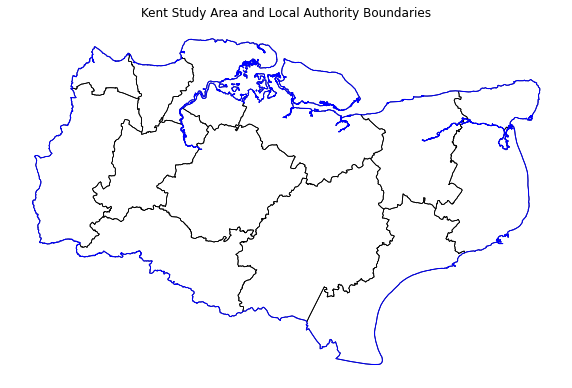

In [17]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the individual local authorities
kent.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.8
)

# Plot the dissolved Kent boundary
kent_boundary.plot(
    ax=ax,
    facecolor="none",
    edgecolor="blue",
    linewidth=1
)

ax.set_title("Kent Study Area and Local Authority Boundaries")
ax.set_axis_off()

plt.show()

In [19]:
kent_boundary.total_bounds

array([542130.8038, 116568.8   , 640164.8   , 179531.13  ])

In [18]:
kent_boundary.to_file(
    "../data/processed/kent_study_area.geojson",
    driver="GeoJSON"
)

PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: '../data/processed/kent_study_area.geojson'